In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# loading data file for customer reviews
df = pd.read_csv('../data/raw/1429_1.csv')
df.head()

C:\Users\anita\AppData\Local\Temp\ipykernel_21636\2094773880.py:2: DtypeWarning: Columns (0: name, 1: reviews.didPurchase) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/1429_1.csv')


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [8]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  str    
 1   name                  27900 non-null  str    
 2   asins                 34658 non-null  str    
 3   brand                 34660 non-null  str    
 4   categories            34660 non-null  str    
 5   keys                  34660 non-null  str    
 6   manufacturer          34660 non-null  str    
 7   reviews.date          34621 non-null  str    
 8   reviews.dateAdded     24039 non-null  str    
 9   reviews.dateSeen      34660 non-null  str    
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs    34660 no

In [22]:
df.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username'],
      dtype='str')

In [9]:
#Null value check
df.isnull().sum()

id                          0
name                     6760
asins                       2
brand                       0
categories                  0
keys                        0
manufacturer                0
reviews.date               39
reviews.dateAdded       10621
reviews.dateSeen            0
reviews.didPurchase     34659
reviews.doRecommend       594
reviews.id              34659
reviews.numHelpful        529
reviews.rating             33
reviews.sourceURLs          0
reviews.text                1
reviews.title               6
reviews.userCity        34660
reviews.userProvince    34660
reviews.username            7
dtype: int64

In [25]:
#Duplicate check
df.duplicated().sum()

print("Exact duplicate rows:", df.duplicated().sum())

print(
    "Duplicate review texts:",
    df["reviews.text"].duplicated().sum()
)

df[df["reviews.text"].duplicated(keep=False)][
    ["name", "reviews.rating", "reviews.text"]
].head()

Exact duplicate rows: 0
Duplicate review texts: 0


,name,reviews.rating,reviews.text


In [29]:
#product analysis
print("Unique products:", df["name"].nunique())
print("Unique brands:", df["brand"].nunique())
print("Unique ASINs:", df["asins"].nunique())
print("Unique categories:", df["categories"].nunique())

Unique products: 48
Unique brands: 6
Unique ASINs: 41
Unique categories: 41


Ratings reviews.rating
5.0    23775
4.0     8541
3.0     1499
1.0      410
2.0      402
Name: count, dtype: int64


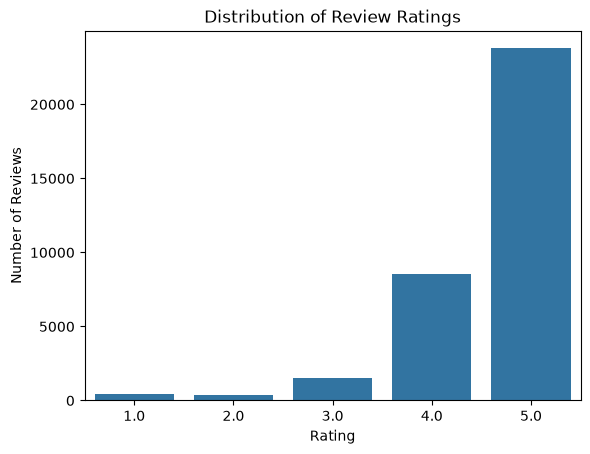

In [ ]:
print("Ratings", df["reviews.rating"].value_counts()) ## count of unique values 

sns.countplot(
    data=df,
    x="reviews.rating",
    order=[1.0, 2.0, 3.0, 4.0, 5.0]
)

plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

In [27]:
#Calculate the three sentiment counts:
# 1–2 → negative
# 3   → neutral
# 4–5 → positive

negative = df["reviews.rating"].isin([1, 2]).sum()
neutral = (df["reviews.rating"] == 3).sum()
positive = df["reviews.rating"].isin([4, 5]).sum()

print("Negative:", negative)
print("Neutral:", neutral)
print("Positive:", positive)

Negative: 812
Neutral: 1499
Positive: 32316


In [28]:
#product analysis
print("Unique products:", df["name"].nunique())
print("Unique brands:", df["brand"].nunique())
print("Unique ASINs:", df["asins"].nunique())
print("Unique categories:", df["categories"].nunique())

Unique products: 48
Unique brands: 6
Unique ASINs: 41
Unique categories: 41


In [30]:
# Recommendation column
print(df["reviews.doRecommend"].value_counts(dropna=False))
pd.crosstab(
    df["reviews.rating"],
    df["reviews.doRecommend"],
    dropna=False
)

reviews.doRecommend
True     32682
False     1384
NaN        594
Name: count, dtype: int64


reviews.doRecommend,False,True,NaN
reviews.rating,,,
1.0,331,25,54
2.0,324,58,20
3.0,532,938,29
4.0,134,8335,72
5.0,63,23326,386
NaN,0,0,33


In [32]:
df["reviews.numHelpful"].describe()

count    34131.000000
mean         0.630248
std         13.215775
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        814.000000
Name: reviews.numHelpful, dtype: float64

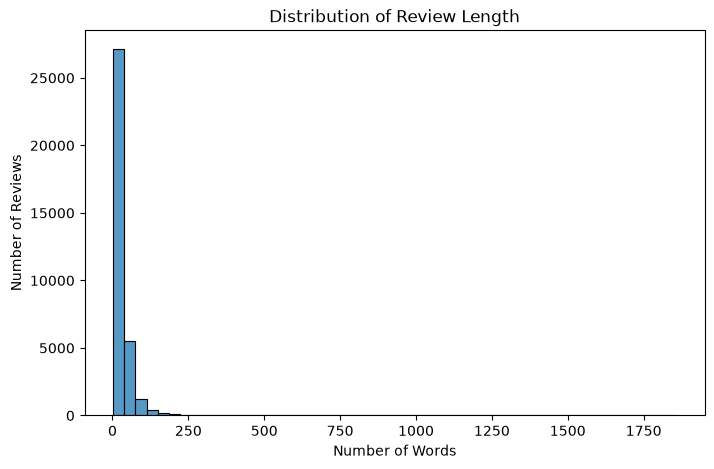

In [33]:
# Review text analysis

df["reviews.text"].str.len().describe()

df["review_word_count"] = df["reviews.text"].str.split().str.len()

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="review_word_count",
    bins=50
)

plt.title("Distribution of Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()

### Key EDA observations
    ## Dataset overview

- The dataset contains 34,660 reviews across 21 columns.
- There are no exact duplicate rows or duplicate review texts.
- The rating distribution is highly imbalanced toward 4- and 5-star reviews.
- Mapping the ratings into three classes results in a strongly imbalanced sentiment distribution, with Positive as the dominant class.
- reviews.text is the primary feature for the sentiment-analysis task, while reviews.title can provide additional textual information.
- Missing ratings and missing review texts need to be handled before modeling.
- Because of the class imbalance, the model will be evaluated using accuracy, precision, recall, F1-score, and a confusion matrix, rather than accuracy alone. 

## Rating distribution
The dataset is strongly skewed toward positive ratings, with 5-star reviews making up the majority of the dataset.
Therefore, the resulting sentiment classes will also be highly imbalanced, with Positive being the dominant class.
This class imbalance should be considered when training and evaluating the sentiment model. Accuracy alone will not be sufficient, so precision, recall, F1-score, and the confusion matrix will also be used. 

| Rating | Reviews |
|---:|---:|
| 1 | 410 |
| 2 | 402 |
| 3 | 1,499 |
| 4 | 8,541 |
| 5 | 23,775 |

For Task 1, ratings will be mapped as:

- **1–2 → Negative**
- **3 → Neutral**
- **4–5 → Positive**

This produces:
| Sentiment | Reviews |
|---|---:|
| Negative | 812 |
| Neutral | 1,499 |
| Positive | 32,316 |